<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [12]</a>'.</span>

In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

### INFO OPTIONS

In [2]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
TRIAL   = OPTIONS.get('trial', 0)
ECONOMY = OPTIONS.get('economy', True)
OPTIONS

{'network': 'fault_edge_former',
 'dataset': 'facies',
 'img_size': [4, 256, 256],
 'step': 3,
 'multiclass': True,
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.05,
 'num_filters': 32,
 'ema': True,
 'n_trials': 1,
 'epochs': 200,
 'trial': 0}

- Memory Usage Clean

In [3]:
if ECONOMY:
    os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

if OPTIONS.get('network') == 'macnn':
    torch.backends.cudnn.deterministic = False

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu128
True
NVIDIA GeForce RTX 5070


- Seed Fix to Prevent Bias

In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


seed_everything(42 + TRIAL)

random seed done


In [5]:
IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
IMG_SIZE, BATCH_SIZE

([4, 256, 256], 2)

In [6]:
DATABASE = f'../Dataset/{OPTIONS.get("dataset")}/DataBase.csv'
df       = pd.read_csv(DATABASE)
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])
OPTIONS['img_size'] = IMG_SIZE
OPTIONS['step']     = int(df['step'].iloc[0])

print(f'{DATABASE}: {len(df)} tiles de shape {IMG_SIZE}, step {OPTIONS["step"]}')
print(df.img_path.iloc[0])
df

../Dataset/facies/DataBase.csv: 7074 tiles de shape (4, 256, 256), step 3
/home/grva-mintcave/Projects/Facies/Dataset/facies/tiles/images/img_00000.npy


,img_path,mask_path,shape,min,max,mean,std,msk_max,step
0,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.229268,0.778868,0.502732,0.037087,3,3
1,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,0.937083,0.502533,0.038899,4,3
2,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.502285,0.046293,4,3
3,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.357488,0.732417,0.502492,0.019550,4,3
4,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.501868,0.083783,4,3
...,...,...,...,...,...,...,...,...,...
7069,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.497164,0.248731,5,3
7070,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.491530,0.283405,5,3
7071,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.500084,0.218975,5,3
7072,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.499803,0.119612,5,3


In [7]:
MULTICLASS = True
classes    = int(df['msk_max'].max()) + 1
classes

6

img: (np.float32(0.22926785), np.float32(0.7788685))
msk: (np.uint8(0), np.uint8(3))


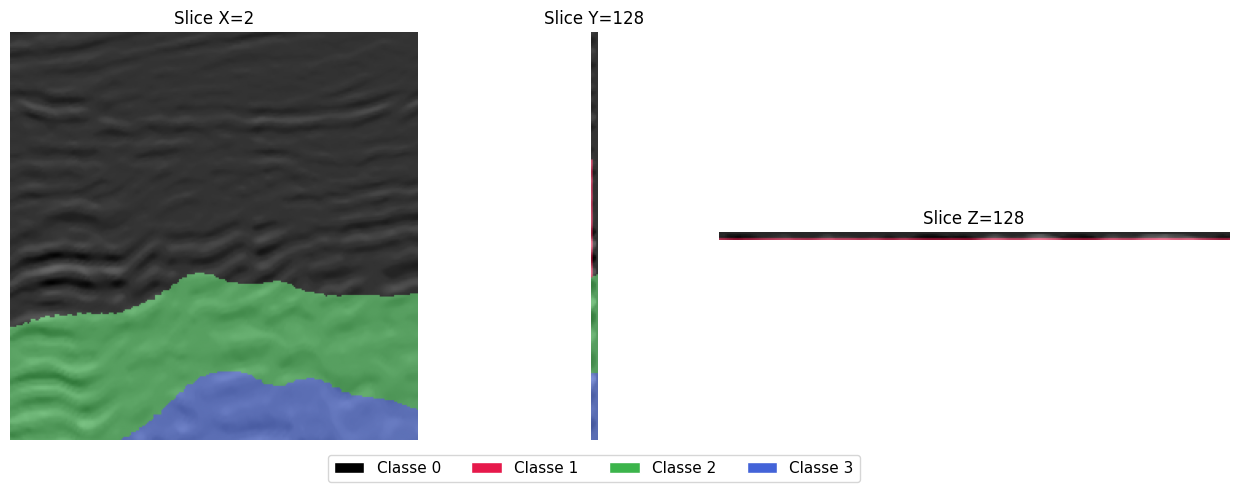

img: (np.float32(0.0), np.float32(0.9370833))
msk: (np.uint8(0), np.uint8(4))


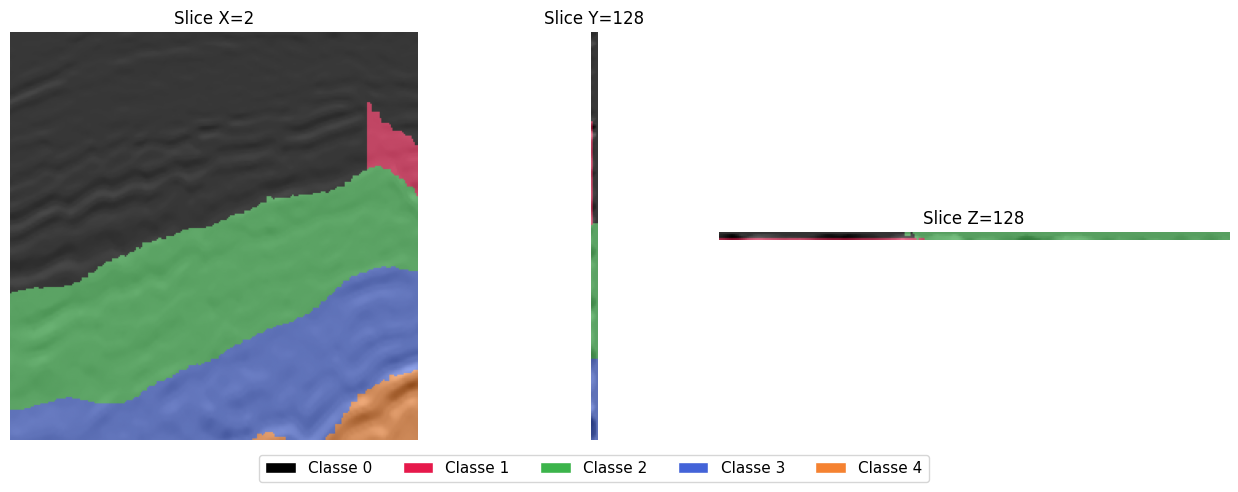

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(4))


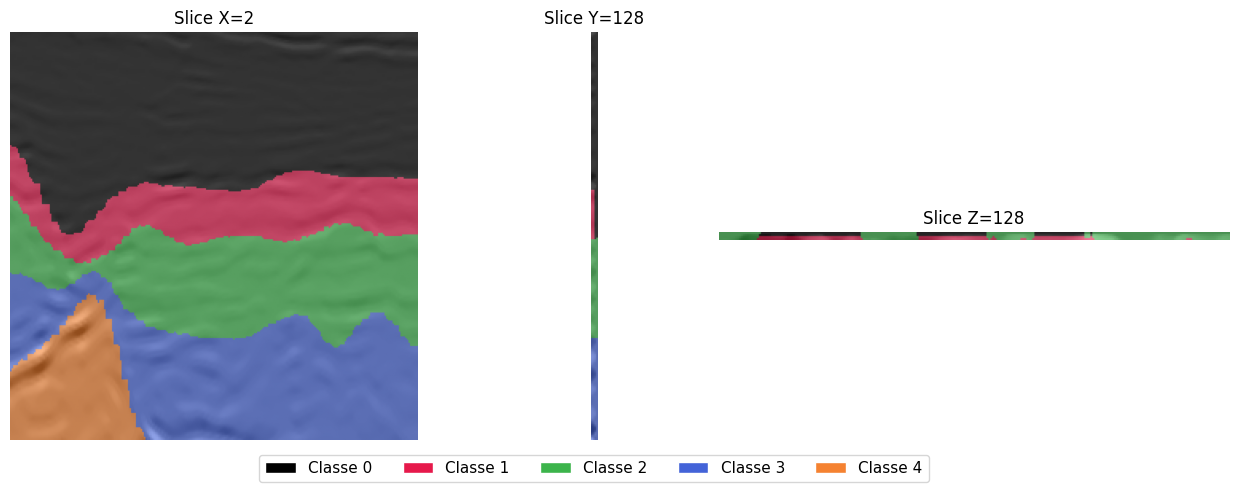

In [8]:
for index in range(3):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

In [9]:
VAL_SIZE  = 0.1
TEST_SIZE = 0.1
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [10]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=VAL_SIZE, random_state=42)
del temp_df

OPTIONS['n_images'] = {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
OPTIONS['n_images']

{'total': 7074, 'train': 5658, 'val': 708, 'test': 708}

# MODELO

In [11]:
from Network.index import ModelNetwork

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [12]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': OPTIONS.get('img_size'),
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
    'deep_supervision': OPTIONS.get('deep_supervision', False),
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'fault_edge_former', 'img_size': (4, 256, 256), 'classes': 6, 'channels': 1, 'dropout': 0.05, 'num_filters': 32, 'lr': 0.0001, 'deep_supervision': False}


ValueError: num_filters=32: a largura base do FaultEdgeFormer e um multiplo dos 9 kernels de Sobel (9 no artigo)

In [ ]:
network.classes

# DATASET

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDataset=CustomDataset(
    df=train_df, 
    multiclass=MULTICLASS
)

valDataset=CustomDataset(
    df=val_df, 
    multiclass=MULTICLASS
)

testDataset=CustomDataset(
    df=test_df, 
    multiclass=MULTICLASS
)

# DATA LOADER

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
NUM_WORKERS = 2

trainLoader = DataLoader(
    trainDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

valLoader = DataLoader(
    valDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

testLoader = DataLoader(
    testDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

In [ ]:
images, masks = next(iter(trainLoader))
img = images[0].squeeze().cpu().numpy()
msk = masks[0].squeeze().cpu().numpy()

print('xTrain Shape: ', img.shape)
print('yTrain Shape: ', msk.shape)
print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
print('yTrain Unique:', np.unique(msk).astype(int))

showTile(img)
showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [ ]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from EMA.index import ModelEMA
from torch import amp
gc.collect()

In [ ]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

### Scheduler

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
# COSSENO QUE ACEITA A CHAMADA DO TRAINER: step(val_loss) PASSARIA A PERDA COMO EPOCA E O LR FICARIA CONSTANTE
class CosineScheduler(CosineAnnealingWarmRestarts):
    def step(self, metrics=None):
        super().step()


class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineScheduler(optimizer, T_0=10, T_mult=2)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [ ]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau', ema=False, use_amp=False):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size 
        
        self.scheduler      = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=OPTIONS.get('patience', 20), mode='max', min_delta=1e-4)

        # PESOS DAS CABECAS AUXILIARES QUANDO A REDE DEVOLVE LISTA (DEEP SUPERVISION), NORMALIZADOS PELA SOMA PARA O train_loss SEGUIR COMPARAVEL ENTRE EXPERIMENTOS
        self.ds_weights = [1.0, 0.5, 0.25, 0.125]

        # PRECISAO MISTA: AS CONVS RODAM EM FLOAT16 E AS PERDAS SEGUEM EM FLOAT32 (ELAS SAEM DO AUTOCAST POR DENTRO)
        self.use_amp = use_amp
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

        # COM EMA A VALIDACAO, O EARLY STOPPING E O TESTE USAM A MEDIA DOS PESOS, NAO O MODELO VIVO
        self.ema = ModelEMA(network.model, decay=0.999) if ema else None

    @property
    def model(self):
        return self.ema.model if self.ema else self.network.model

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.model, val_iou):
                break
            
        # O MELHOR ESTADO (DO EMA, SE LIGADO) VAI PARA O MODELO VIVO, QUE E O QUE SE SALVA E PLOTA
        self.early_stopping.restore_best(self.network.model)
        if self.ema:
            self.ema.model.load_state_dict(self.network.model.state_dict())
    
    def criterion(self, model, logits, masks):
        if isinstance(logits, (list, tuple)):
            weights = self.ds_weights[:len(logits)]
            loss    = sum(w * self.loss(o, masks) for w, o in zip(weights, logits)) / sum(weights)
        else:
            loss = self.loss(logits, masks)

        return model.compose(loss) if hasattr(model, 'compose') else loss

    def train(self, loader=trainLoader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.criterion(self.network.model, logits, masks)
                logits = logits[0] if isinstance(logits, (list, tuple)) else logits   # o iou e o da saida principal
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()

            if self.ema:
                self.ema.update(self.network.model)
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=valLoader):
        self.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.model(imgs)
                    val_loss += self.criterion(self.model, logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)


EMA    = bool(OPTIONS.get('ema', False))
EPOCHS = OPTIONS.get('epochs', 200)

trainer = Trainer(network, loss, epochs=EPOCHS, scheduler=scheduler, ema=EMA, use_amp=ECONOMY)
trainer.start()

In [ ]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou') for h in history], 'r', label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])
    
    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [ ]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

In [ ]:
from torchmetrics.classification import MulticlassJaccardIndex


def getClasses(network, loader, save=None):
    iou_por_classe = MulticlassJaccardIndex(num_classes=network.classes, average='none').to(network.device)
    network.model.eval()

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(network.device)
            masks = masks.to(network.device).squeeze(1)

            logits = network.model(imgs)
            preds  = torch.argmax(logits, dim=1)
            iou_por_classe.update(preds, masks)

    ious = iou_por_classe.compute().cpu().numpy()
    ious = {str(i): float(val) for i, val in enumerate(ious)}

    class_keys = sorted([k for k in ious.keys() if k != 'mean'], key=lambda x: int(x) if x.isdigit() else x)
    sorted_ious = {k: ious[k] for k in class_keys}
    sorted_ious.update({'mean': test_iou})

    plt.figure(figsize=(17, 6))
    Plotter(sorted_ious)

    if save:
        plt.savefig(save)
        plt.close()

    return ious


if network.multiclass:
    getClasses(network, testLoader)
    plt.show()

In [ ]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    if network.multiclass:
        solid_cmap, cmap = faciesCmaps(network.classes)
        mx, my, mz = img_np.shape[0] // 2, img_np.shape[1] // 2, img_np.shape[2] // 2
        planes = lambda v: [np.array(v[mx, :, :]), np.rot90(np.array(v[:, :, mz]), -1), np.array(v[:, my, :])]
        ig, mg, pg = planes(img_np), planes(mask_np), planes(pred_np)

        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        for j in range(3):
            for r, layer in enumerate([mg, pg]):
                axes[r, j].imshow(ig[j], cmap='gray')
                axes[r, j].imshow(layer[j], cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
                axes[r, j].axis('off')

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=min(network.classes, 7), bbox_to_anchor=(0.5, 0.01), fontsize=11)

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if savePath:
            plt.savefig(savePath, bbox_inches='tight', dpi=200); plt.close(fig)
        else:
            plt.show()
        return

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    
    inters = (is_gt & is_pred)   # Acertos / Interseção
    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [ ]:
from datetime import datetime
import json, inspect

In [ ]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

In [ ]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [ ]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'economy': ECONOMY,
        'ema': EMA,
        'trial': TRIAL,
        'val_iou':  trainer.early_stopping.best,
        'test_iou': test_iou
    },
    'processing': OPTIONS,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'), 
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)   

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)